# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

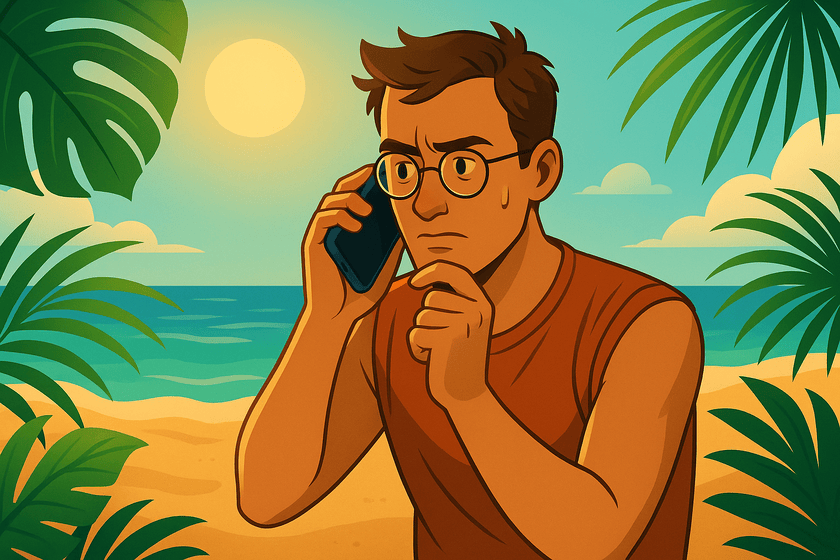

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [201]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Wczytanie danych

In [202]:
import pandas as pd
data_path = '/content/drive/MyDrive/ML/titanic.csv'
dane=pd.read_csv(data_path)
dane2 = dane.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
print(dane2.head())



   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


Predykowaną klasę oznacza zmienna Survived
Zmienna Survived oznacza predykowaną klasę

## Sprawdzenie i zmiana typów danych na właściwe


In [203]:
print(dane2.dtypes)
dane2['Sex'] = dane2['Sex'].map({'female': 0, 'male': 1}).astype(int)
dane2['Survived'] = dane2['Survived'].astype(int)
dane2['Pclass'] = dane2['Pclass'].astype(int)
dane2 = pd.get_dummies(dane2, columns=['Embarked'], drop_first=True, dtype=int)
print(dane2.dtypes)
print(dane2.head())



Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q      int64
Embarked_S      int64
dtype: object
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0      1      0   7.2500           0           1
1         1       1    0  38.0      1      0  71.2833           0           0
2         1       3    0  26.0      0      0   7.9250           0           1
3         1       1    0  35.0      1      0  53.1000           0           1
4         0       3    1  35.0      0      0   8.0500           0           1


## Obsługa wartości brakujących i analiza rozkładów dla zmiennych ciągłych

In [204]:
#Patrzę ile jest wartości brakujących dla każdej kolumny
print(dane2.isna().sum())

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare           98
Embarked_Q      0
Embarked_S      0
dtype: int64


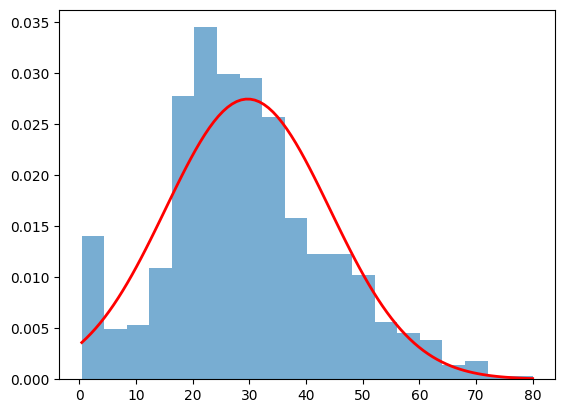

In [205]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
x=dane2['Age']
plt.hist(x, bins=20, density=True, alpha=0.6)

mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)

plt.show()




#### Rozkład zmiennej jest prawoskośny.

In [206]:
#Rozkład zmiennej Age nie jest normalny, więc zastępuję wartości brakujące medianą.
dane2['Age'] = dane2['Age'].fillna(dane2['Age'].median())

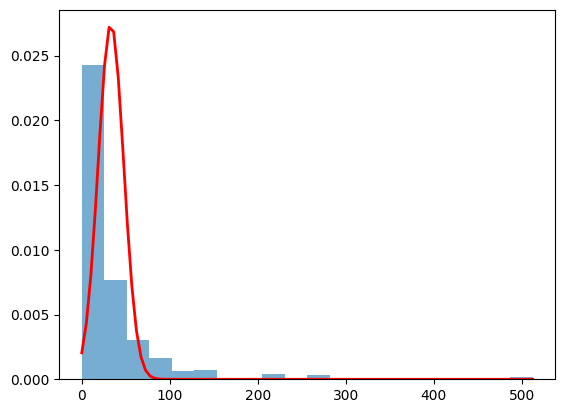

In [207]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
x1=dane2['Fare']
plt.hist(dane2['Fare'], bins=20, density=True, alpha=0.6)

mi1 = x1.mean()
sigma1 = x1.std()

xx1 = np.linspace(x1.min(), x1.max(), 100)
yy1 = norm.pdf(xx1, mi1, sigma)

plt.plot(xx1, yy1, 'r-', linewidth=2)

plt.show()

#### Rozkład zmiennej Fare jest prawoskośny

In [208]:
#Rozkład zmiennej Fare nie jest normalny, więc zastępuję wartości brakujące medianą.
dane2['Fare'] = dane2['Fare'].fillna(dane2['Fare'].median())

## Wizualizacja


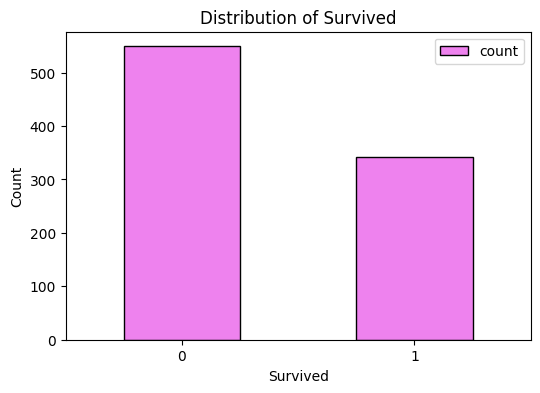

In [209]:
#rozkład zmiennej Survived
counts = dane2['Survived'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='violet', edgecolor='black')
plt.title(f'Distribution of {'Survived'}')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Wniosek: Więcej osób nie przeżyło niż przeżyło

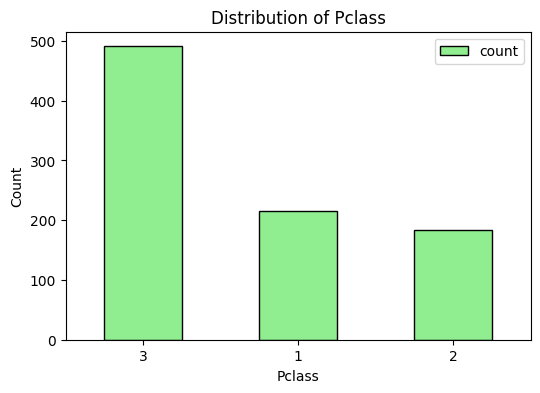

In [210]:
#rozkład zmiennej Pclass
counts = dane2['Pclass'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title(f'Distribution of {'Pclass'}')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Najwięcej było podróżujących w klasie 3

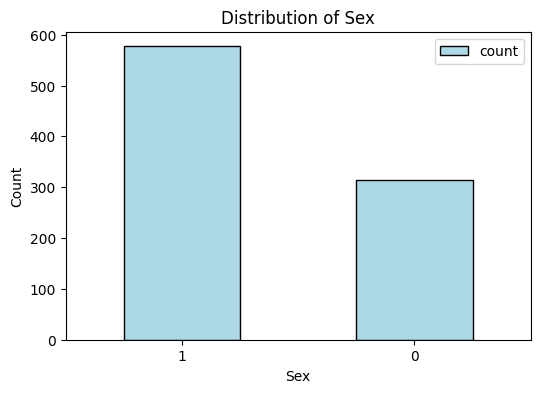

In [211]:
#rozkład zmiennej Sex
counts = dane2['Sex'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title(f'Distribution of {'Sex'}')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Więcej było mężczyzn niż kobiet

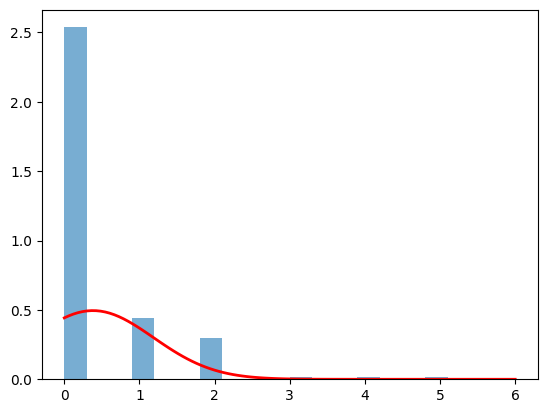

In [212]:
#Rozkład zmiennej Parch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
x=dane2['Parch']
plt.hist(dane2['Parch'], bins=20, density=True, alpha=0.6)

mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)

plt.show()

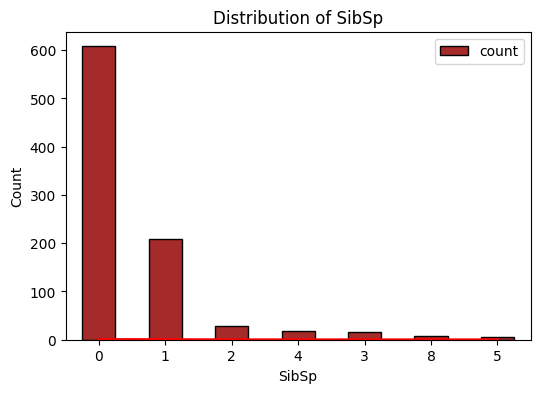

In [213]:
#rozkład zmiennej SibSp
counts = dane2['SibSp'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='brown', edgecolor='black')
plt.title(f'Distribution of {'SibSp'}')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
mi = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 100)
yy = norm.pdf(xx, mi, sigma)

plt.plot(xx, yy, 'r-', linewidth=2)
plt.show()


Najczęściej podróżują bez rodzeństwa i partnera.

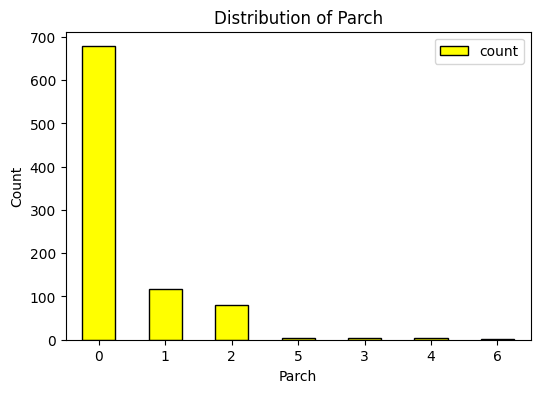

In [214]:
#rozkład zmiennej Parch
counts = dane2['Parch'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='yellow', edgecolor='black')
plt.title(f'Distribution of {'Parch'}')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Najczęściej podróżują osoby bez rodziców i dzieci

## Sprawdzenie czy występują wartości odstające za pomocą wykresów pudełkowych

In [215]:
#funkcja rysująca boxploty
import seaborn as sns
def boxplot(df, column_name):
  plt.figure(figsize=(5, 4))
  sns.boxplot(data=df[column_name], color='magenta')
  plt.title(f"Distribution of {column_name} (boxplot)")
  plt.ylabel(column_name)
  plt.tight_layout()
  plt.show()

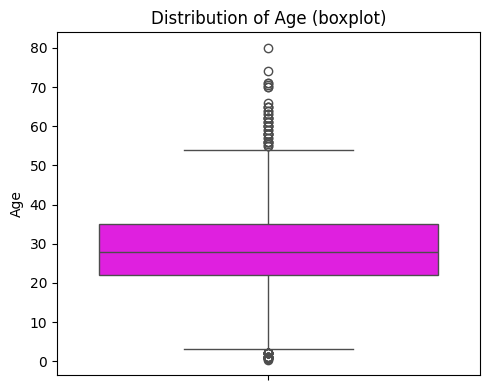

In [216]:
#Wykres pudełkowy zmiennej Age
boxplot(dane2, 'Age')

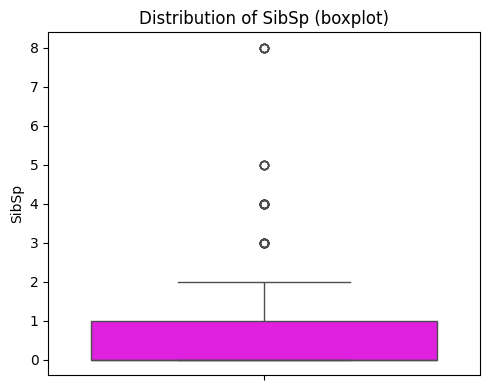

In [217]:
#Wykres pudełkowy zmiennej Sp
boxplot(dane2, 'SibSp')

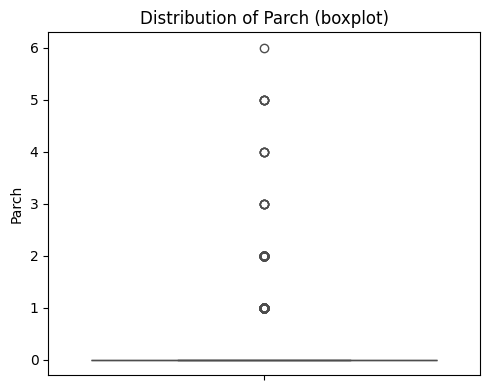

In [218]:
#Wykres pudełkowy zmiennej Parch
boxplot(dane2, 'Parch')

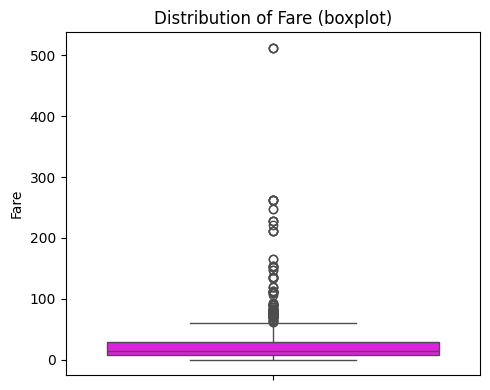

In [219]:
#Wykres pudełkowy zmiennej Fare
boxplot(dane2, 'Fare')

WNIOSEK: Wartości odstające występują we wszystkich analizowanych zmiennych tj.Age, SbSp, Parch, Fare. Co ciekawe, wykres Parch wygląda jakby były tam same wartości odstajace. Wynika to z tego, że analizowana osoba podróżowała zazwyczaj bez dzieci i rodziców (patrz:niżej).

In [220]:

sentiment_counts = dane['Parch'].value_counts()
print(sentiment_counts)

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


## Standaryzacja



Wszystkie zmienne standaryzuję za pomocą robust_scaler, ponieważ każda ma wartości odstające.

In [221]:
def robust_scaler_wiele(df, nazwy_kolumn):
    df2 = df.copy()

    for kolumna in nazwy_kolumn:
        IQR = df2[kolumna].quantile(0.75) - df2[kolumna].quantile(0.25)
        median = df2[kolumna].median()

        if IQR == 0:
            IQR = 1.0

        df2[kolumna] = (df2[kolumna] - median) / IQR

    return df2
dane2_scaled = robust_scaler_wiele(dane2, ['Age', 'SibSp', 'Parch', 'Fare'])



In [222]:
# robust_scaler(dane2, 'Age')
# robust_scaler(dane2,'SibSp')
# robust_scaler(dane2,'Parch')
# robust_scaler(dane2, 'Fare')
# dane2_scaled = robust_scaler_wiele(dane2, ['Age', 'SibSp', 'Parch', 'Fare'])

## Dodanie dwóch kolumn

In [223]:
#dodanie kolumny FCount będącą sumą wszystkich członków rodziny na pokładzie
dane2['FCount']=(dane2['SibSp']+dane2['Parch']).astype(int)


In [224]:
#dodanie kolumny sprawdzającej czy pasażer
dane2['IsChild'] = (dane2['Age'] < 18).astype(int)


In [225]:
dane2_scaled = robust_scaler_wiele(dane2, ['Age', 'SibSp', 'Parch', 'Fare', 'FCount'])

## Korelacja

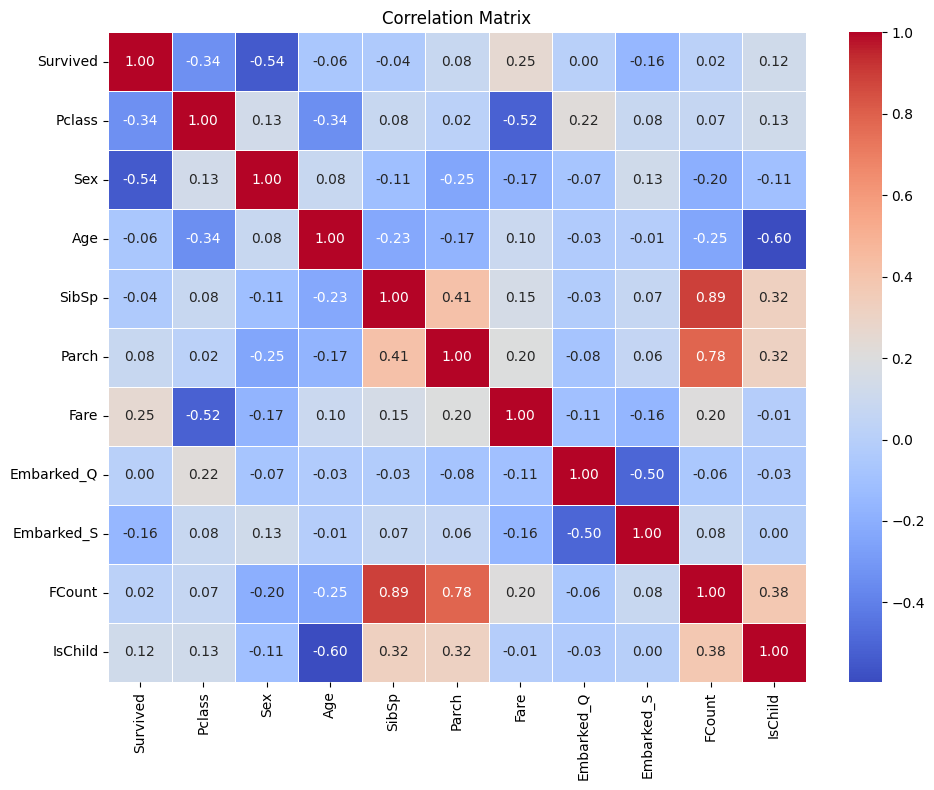

In [226]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(df):
  corr = df.corr(numeric_only=True)
  plt.figure(figsize=(10, 8))
  sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
  plt.title('Correlation Matrix')
  plt.tight_layout()
  plt.show()
plot_correlation_matrix(dane2)

Największa korelacja jest między zmiennymi SibSP a Parch.

<Axes: xlabel='SibSp', ylabel='Parch'>

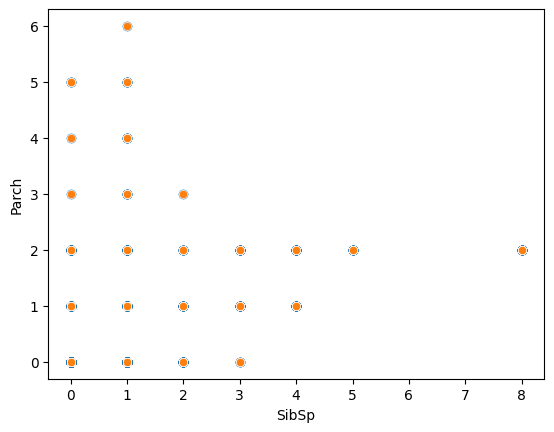

In [227]:
plt.scatter(dane2['SibSp'], dane2['Parch'])
sns.scatterplot(x='SibSp', y='Parch', data=dane2)

## Wnioski z poprzedniego zadania

Jest duża korelacja między survived i sex oraz survived a PClass

## Podział na zbiór treningowy i uczący

W badaniach będę korzystać z dwóch metryk: ConfusionMatrix i Accuracy. Dzięki accuracy mogę porównać dokładność mojego modelu z DummyClassifier, a dzięki ConfusionMatrix mogę zrozumieć co zrobił dobrze a co źle mój model

In [228]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
y=dane2_scaled['Survived']
X=dane2_scaled.drop(columns=['Survived'])
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

## DummyClassifier

In [229]:
model = DummyClassifier(strategy = 'most_frequent')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.66      1.00      0.80       177
           1       0.00      0.00      0.00        91

    accuracy                           0.66       268
   macro avg       0.33      0.50      0.40       268
weighted avg       0.44      0.66      0.53       268



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[177,   0],
       [ 91,   0]])

## SVC

In [230]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc = SVC(kernel='rbf', random_state=42)

svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
print(f"Dokładność modelu SVC: {accuracy_score(y_test, y_pred)}")
confusion_matrix(y_test, y_pred)



Dokładność modelu SVC: 0.7910447761194029


array([[150,  27],
       [ 29,  62]])

Wniosek: Model poprawnie wykonał swoje zdanie: 0.79>0.62. Model nie został przeuczony.

## knn

In [231]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.inspection import DecisionBoundaryDisplay

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred=knn.predict(X_test)
print(f"{accuracy_score(y_test, y_pred)}")
confusion_matrix(y_test, y_pred)


0.7947761194029851


array([[150,  27],
       [ 28,  63]])

Wniosek: Model poprawnie wykonał swoje zdanie: 0.82>0.62. Model nie został przeuczony.

## Dobór parametrów-svc

In [232]:


from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Siatka dla klasyfikacji
siatka_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

szukaj_svc = GridSearchCV(
    SVC(random_state=42),
    siatka_svc,
    cv=5,
    scoring='accuracy'
)
szukaj_svc.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj_svc.best_params_)
print("wynik kroswalidacji: ", round(szukaj_svc.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_svc.score(X_test, y_test), 3))

najlepsze ustawienia: {'C': 10, 'gamma': 'scale'}
wynik kroswalidacji:  0.835
wynik na tescie:      0.787


In [233]:

from sklearn.neighbors import KNeighborsClassifier

siatka_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

szukaj_knn = GridSearchCV(
    KNeighborsClassifier(),
    siatka_knn,
    cv=5,
    scoring='accuracy'
)
szukaj_knn.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj_knn.best_params_)
print("wynik kroswalidacji: ", round(szukaj_knn.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_knn.score(X_test, y_test), 3))

najlepsze ustawienia: {'n_neighbors': 20, 'p': 1, 'weights': 'distance'}
wynik kroswalidacji:  0.82
wynik na tescie:      0.769


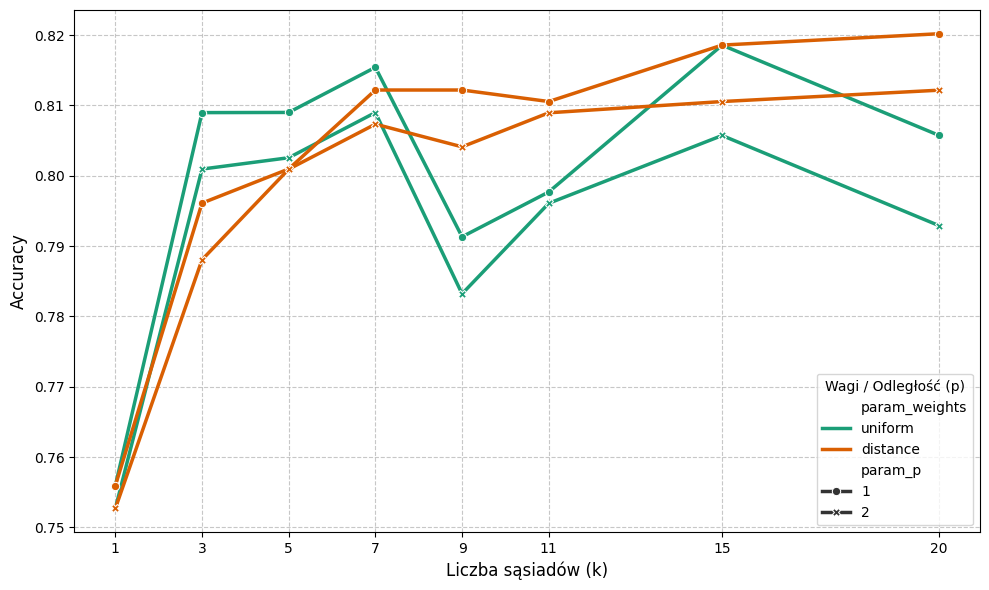

In [240]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

wyniki_knn = pd.DataFrame(szukaj_knn.cv_results_)

wyniki_knn["param_n_neighbors"] = wyniki_knn["param_n_neighbors"].astype(int)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=wyniki_knn,
    x="param_n_neighbors",
    y="mean_test_score",
    hue="param_weights",
    palette="Dark2",
    style="param_p",
    markers=True,
    dashes=False,
    linewidth=2.5,
)


plt.xlabel("Liczba sąsiadów (k)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(szukaj_knn.param_grid["n_neighbors"])
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Wagi / Odległość (p)")
plt.tight_layout()
plt.show()

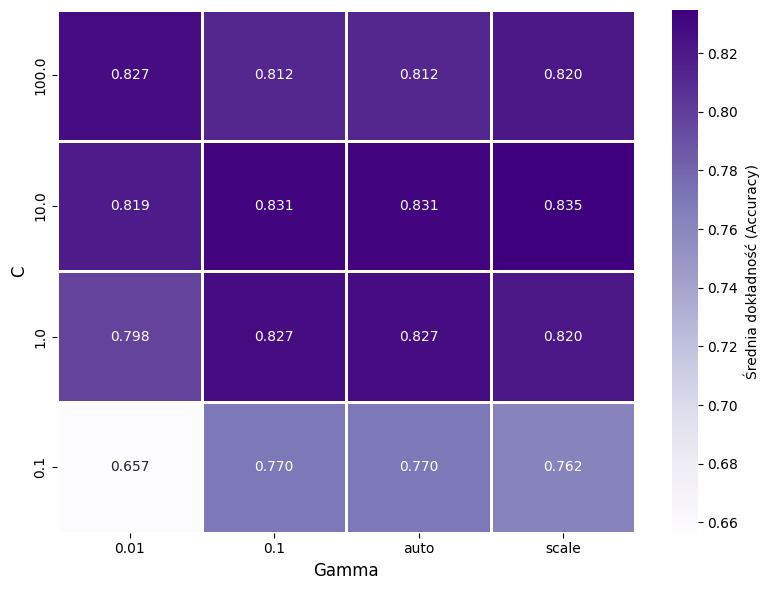

In [238]:

wyniki_svc = pd.DataFrame(szukaj_svc.cv_results_)

pivot_svc = wyniki_svc.pivot(
    index="param_C",
    columns="param_gamma",
    values="mean_test_score"
)

pivot_svc.index = [str(x) for x in pivot_svc.index]
pivot_svc.columns = [str(x) for x in pivot_svc.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_svc,
    annot=True,
    cmap="Purples",
    fmt=".3f",
    cbar_kws={"label": "Średnia dokładność (Accuracy)"},
    linewidths=1,
)


plt.xlabel("Gamma", fontsize=12)
plt.ylabel("C", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Ogólne wnioski: Najlepszym modelem okazał się knn( dla 'C': 100, 'gamma': 0.01), ponieważ w przypadku SVC nastąpiło lekkie przeuczenie dla najlepszych parametrów (wynik na teście jest mniejszy niż w kroswalidacji)